# Book Genere Classification and Recommender system

### Abstract :
This project aims to develop a book classification and recommendation system by leveraging data mining concepts. Key steps include preprocessing book descriptions, extracting features with nlp methods, applying machine learning for genre prediction, and implementing content-based recommendations using large language models. A detailed step by step procedure of the project is given below:

1. EDA and Data Processing

Goal: Prepare the dataset and analyse it. Understand the data distribution and then prepare data by cleaning, transforming, and encoding text data.

	1.	Clean the Description Column:
	•	Remove missing values in the Description and Genre columns.
	•	Replace or remove special characters, numbers, and HTML tags.
	2.	Normalize the Text:
	•	Convert all text to lowercase to maintain consistency.
	•	Remove stopwords (e.g., “the”, “and”, “in”) using libraries like NLTK or spaCy.
	•	Apply stemming or lemmatization to reduce words to their root forms.
	3.	Feature Extraction:
	•	Use TF-IDF (Term Frequency-Inverse Document Frequency) to transform the text into numerical features, capturing word importance in the Description.
	•	Alternatively, use pre-trained embeddings like Word2Vec or BERT for richer semantic representations.

2. Dimension Reduction

Goal: Simplify high-dimensional feature space while preserving key information.

	1.	Principal Component Analysis (PCA):
	•	Reduce the dimensionality of TF-IDF features while retaining maximum variance.
	•	Choose the number of components based on the explained variance ratio.
	2.	t-SNE Visualization:
	•	Use t-SNE (t-Distributed Stochastic Neighbor Embedding) to project high-dimensional data into a 2D or 3D space.
	•	Visualize clusters of books to explore latent patterns in their descriptions.


3. Predictive Modeling

Goal: Build and evaluate a classification model to predict book genres.

	1.	Model Selection:
	•	Train classifiers like Logistic Regression, Decision Trees, Random Forests, or SVM.
	•	For advanced approaches, use Neural Networks (e.g., Multi-Layer Perceptrons).
	2.	Model Training:
	•	Split the data into training and testing sets (e.g., 80/20 split).
	•	Train the model on the processed Description features (X) and genres (y).
	3.	Evaluation:
	•	Evaluate model performance using:
	•	Accuracy, Precision, Recall, and F1-score.
	•	Confusion matrix for detailed insights.

4. Recommendation Systems

Goal: Enhance the chatbot with personalized book recommendations.

	1.	Content-Based Recommendations:
	•	Recommend books based on similar descriptions or genres.
	•	Use cosine similarity on TF-IDF or embeddings to find similar books.
	2.	Collaborative Filtering:
	•	If user ratings are available, use collaborative filtering techniques:
	•	Matrix Factorization: Decompose user-book matrices to identify patterns.
	•	Example: Singular Value Decomposition (SVD).

5. Large Language Models (LLMs)

Goal: Using pre-trained language models for chatbot interaction.

	1.	Integration:
	•	Use GPT models (e.g., OpenAI GPT-4) or Hugging Face transformers to understand user queries.
	•	Fine-tune a model with your dataset to make responses more context-specific.
	2.	Capabilities:
	•	Handle queries about books, genres, and authors.
	•	Generate summaries or insights for user-provided book titles.
	.   Ask questions like " Give similar books to XXX" based on books in the database .. or "Give more books from the author XXX" based on authors in the dataset. 



### **STEP 1 : Loading and exploring the data**


In [2]:
!pip install pandas nltk scikit-learn matplotlib seaborn wordcloud


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.5 MB 7.1 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.5 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 11.5/11.5 MB 21.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 26.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   --------------- ------------------------ 4.2/11.0 MB 50.4 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 36.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   -------------------------------------- - 7.6/7.8 MB 39.3 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 28.6 MB/s eta 0:00:00
   -------------------

In [2]:
# Import necessary libraries
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [4]:

# Load the dataset
file_path = 'BooksDataSet_project.csv'  # Update with your dataset path
df = pd.read_csv(file_path)
print(df.head(20))

    Unnamed: 0                                               Book  \
0            0                              To Kill a Mockingbird   
1            1  Harry Potter and the Philosopher’s Stone (Harr...   
2            2                                Pride and Prejudice   
3            3                          The Diary of a Young Girl   
4            4                                        Animal Farm   
5            5                                  The Little Prince   
6            6                                               1984   
7            7                                   The Great Gatsby   
8            8                             The Catcher in the Rye   
9            9                              The Lord of the Rings   
10          10                                     The Book Thief   
11          11                                          Jane Eyre   
12          12  The Chronicles of Narnia (Chronicles of Narnia...   
13          13                    

In [5]:
# Exploratory Data Analysis
# Step 1: Basic Exploration
print("Dataset Overview:")
print(df.head())  # View first few rows
print("\nMissing Values:")
print(df.isnull().sum())  # Check for missing values
print("\nDataset Info:")
print(df.info())  # Overview of data types and non-null counts


Dataset Overview:
   Unnamed: 0                                               Book  \
0           0                              To Kill a Mockingbird   
1           1  Harry Potter and the Philosopher’s Stone (Harr...   
2           2                                Pride and Prejudice   
3           3                          The Diary of a Young Girl   
4           4                                        Animal Farm   

          Author                                        Description  \
0     Harper Lee  The unforgettable novel of a childhood in a sl...   
1   J.K. Rowling  Harry Potter thinks he is an ordinary boy - un...   
2    Jane Austen  Since its immediate success in 1813, Pride and...   
3     Anne Frank  Discovered in the attic in which she spent the...   
4  George Orwell  Librarian's note: There is an Alternate Cover ...   

                                          Categories  Avg_Rating Num_Ratings  \
0  ['Classics', 'Fiction', 'Historical Fiction', ...        4.27  


Missing Values in Each Column:
Unnamed: 0      0
Book            0
Author          0
Description    77
Categories      0
Avg_Rating      0
Num_Ratings     0
Type            0
Genre           0
dtype: int64


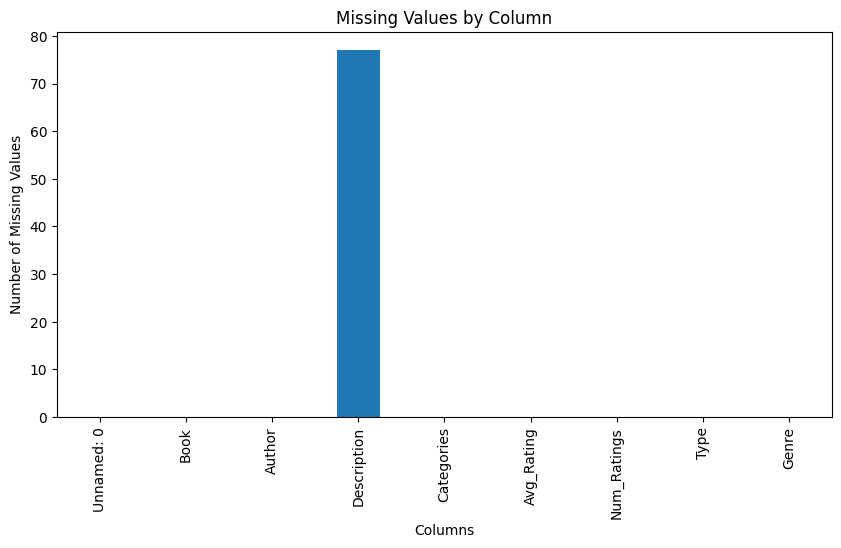

In [6]:
# Step 2: Check Missing Values
print("\nMissing Values in Each Column:")
missing_values = df.isnull().sum()
print(missing_values)

# Plot the missing values
missing_values.plot(kind='bar', figsize=(10, 5), title="Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()


Genre Distribution:
Genre
Fiction                  2497
Romance novel            1477
Fantasy                  1287
Other                     635
Thriller                  597
Historical Fiction        575
Horror                    567
Science fiction           462
Biography                 374
Mystery                   276
Literary fiction          271
Young adult               221
Historical                115
Adventure fiction         111
Autobiographies            78
Classics                   65
Contemporary romance       62
Children's literature      59
Philosophy                 42
Women's fiction            31
Business                   29
Fairy tale                 24
Adventure                  24
Childrens                  20
Crime fiction              20
Mystery thriller           17
Western fiction             9
Magical Realism             9
Action                      9
Science                     8
High fantasy                8
Comedy                      6
Travel       

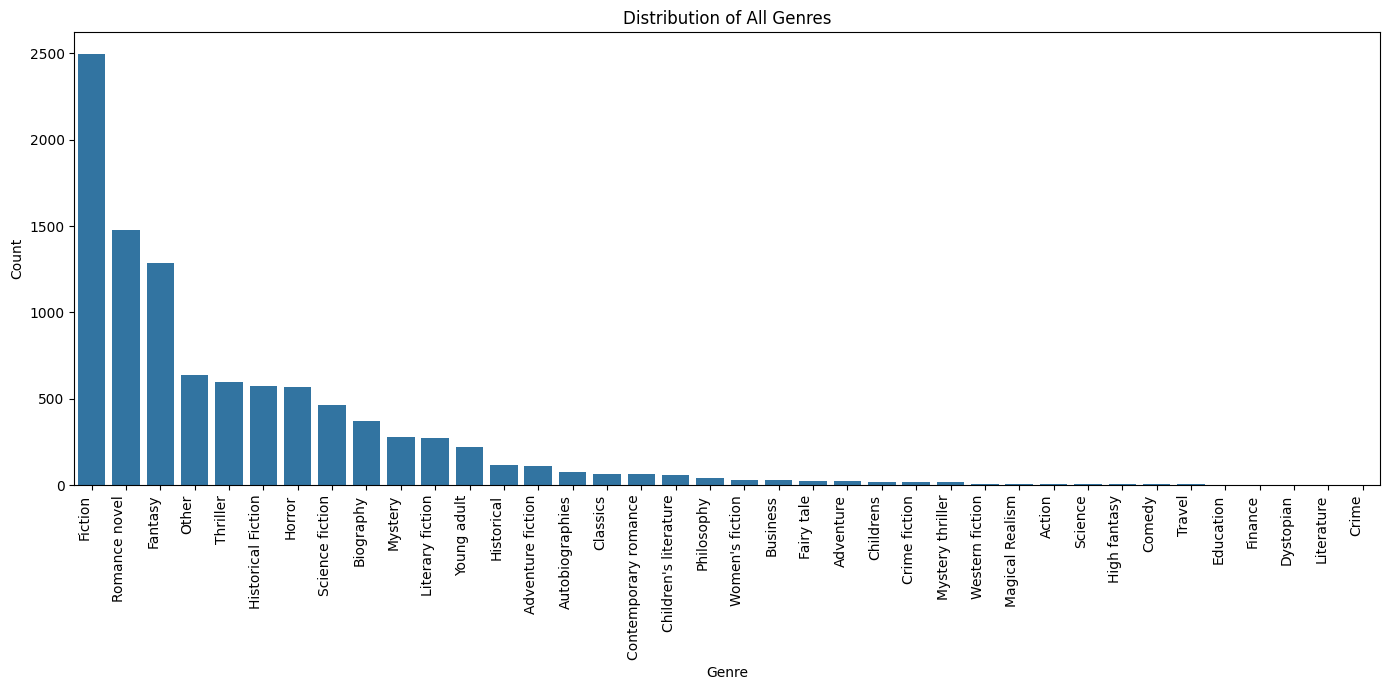

In [7]:
# Step 3 : Plot distribution of all genres
print("\nGenre Distribution:")
genre_counts = df['Genre'].value_counts()  # Include all genres
print(genre_counts)

# Plot the distribution of all genres
plt.figure(figsize=(14, 7))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.title('Distribution of All Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

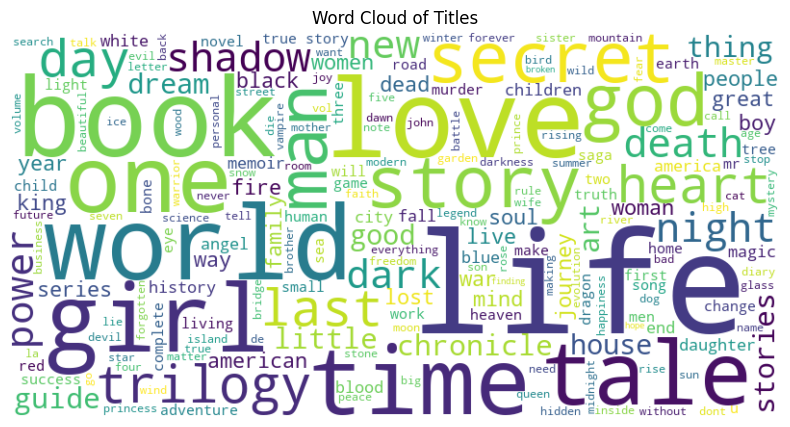

In [8]:

# Step 4: Most Frequent Words in Titles
from collections import Counter
import re

def preprocess_title(title):
    # Remove special characters and numbers, then split into words
    words = re.sub(r'[^a-zA-Z\s]', '', str(title)).lower().split()
    return words


# Combine all titles into one list of words
all_title_words = []
df['Book'].dropna().apply(lambda x: all_title_words.extend(preprocess_title(x)))

# Get the most common words
title_word_counts = Counter(all_title_words)
most_common_words = title_word_counts.most_common(20)


# Generate a word cloud for titles
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_title_words))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Titles')
plt.show()





Distribution of Average Ratings:


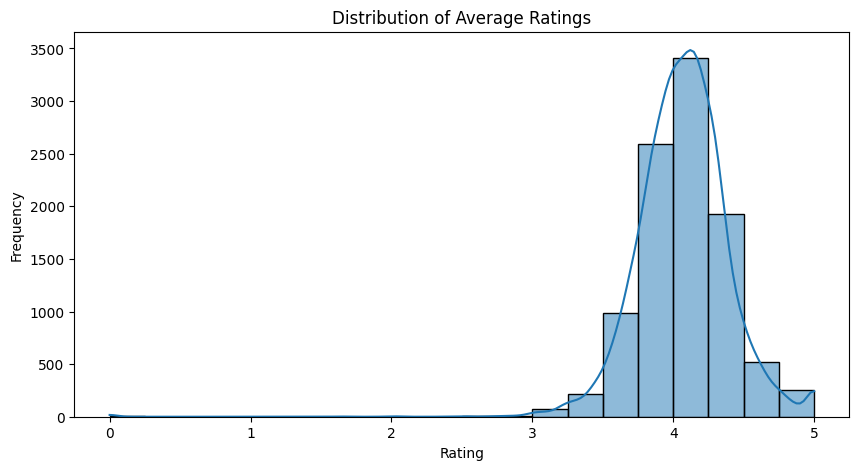

In [9]:

# Step 5: Distribution of Average Ratings
print("\nDistribution of Average Ratings:")
plt.figure(figsize=(10, 5))
sns.histplot(df['Avg_Rating'].dropna(), bins=20, kde=True)
plt.title('Distribution of Average Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [10]:

# Step 7: Summary of EDA
print("\nEDA Summary:")
print(f"Total Books: {len(df)}")
print(f"Unique Genres: {df['Genre'].nunique()}")
print(f"Most Common Genre: {df['Genre'].mode()[0]}")
print(f"Most Frequent Word in Titles: {most_common_words[0][0]} ({most_common_words[0][1]} occurrences)")


EDA Summary:
Total Books: 10000
Unique Genres: 38
Most Common Genre: Fiction
Most Frequent Word in Titles: the (5989 occurrences)


The dataset contains 10,000 books with key columns like Description and Genre. The Description column has 77 missing values, which will be removed as it is critical for genre classification. The Genre column includes 38 unique categories, with a clear imbalance: dominant genres like Fiction (2497 entries) and Romance novel (1477 entries) vastly outnumber minority genres such as Dystopian (2 entries). Imbalance needs to be addressed to improve model performance

### **STEP 2: Data Preprocessing**

In [9]:
# Remove rows with missing values in the Description column
df = df.dropna(subset=['Description'])

# Verify that missing values are handled
print("Missing Values After Removal:")
print(df.isnull().sum())

Missing Values After Removal:
Unnamed: 0     0
Book           0
Author         0
Description    0
Categories     0
Avg_Rating     0
Num_Ratings    0
Type           0
Genre          0
dtype: int64


In [10]:
# Step 2: Address Class Imbalance
from sklearn.utils import resample

# Separate majority and minority classes
majority = df[df['Genre'] == 'Fiction']
minority = df[df['Genre'] != 'Fiction']

# # Option 1: Undersample Majority Class
# majority_downsampled = resample(majority,
#                                 replace=False,
#                                 n_samples=1000,  # Keep the size reasonable
#                                 random_state=42)

# # Option 2: Oversample Minority Classes
# minority_upsampled = resample(minority,
#                               replace=True,
#                               n_samples=2000,  # Match majority size or desired count
#                               random_state=42)
print(len(majority))
print(len(minority))
# # Option 1: Undersample Majority Class to match Minority class size
# majority_downsampled = resample(majority,
#                                 replace=False,  # No replacement, sample size must be <= number of samples in majority class
#                                 n_samples=2000,  # Match the size of the minority class
#                                 random_state=42)

# Option 2: Oversample Minority Classes (if needed)
minority_upsampled = resample(minority,
                              replace=True,  # Allow replacement to oversample
                              n_samples=10000,  # Match majority size or desired count
                              random_state=42)


# # Combine chosen balanced data
df_balanced = pd.concat([majority, minority_upsampled])

# Check new distribution
print("Class Distribution After Balancing:")
print(df_balanced['Genre'].value_counts())

2488
7435
Class Distribution After Balancing:
Genre
Fiction                  2488
Romance novel            2004
Fantasy                  1780
Horror                    770
Thriller                  764
Other                     762
Historical Fiction        715
Science fiction           631
Biography                 482
Mystery                   401
Literary fiction          336
Young adult               335
Historical                160
Adventure fiction         145
Autobiographies            96
Classics                   94
Contemporary romance       89
Children's literature      63
Philosophy                 59
Business                   41
Women's fiction            41
Adventure                  35
Fairy tale                 31
Crime fiction              23
Childrens                  23
Action                     22
Mystery thriller           18
Western fiction            14
Comedy                     12
Magical Realism            11
Dystopian                  10
Science           

In [11]:
# Merge rare genres into broader categories and remove those with fewer than 10 samples
def merge_rare_genres(genre):
    # Define merging rules
    merge_rules = {
        "High fantasy": "Fantasy",
        "Childrens": "Children's literature",
        "Adventure": "Adventure fiction",
    }
    # Apply merging rules
    if genre in merge_rules:
        return merge_rules[genre]
    return genre

# Apply merging rules
df_balanced['Genre'] = df_balanced['Genre'].apply(merge_rare_genres)

# Remove genres with fewer than 10 samples
genre_counts = df_balanced['Genre'].value_counts()
rare_genres = genre_counts[genre_counts < 10].index
df_balanced = df_balanced[~df_balanced['Genre'].isin(rare_genres)]

# Verify the updated genre distribution
updated_genre_counts = df_balanced['Genre'].value_counts()
print("Updated Genre Distribution:")
print(updated_genre_counts)

Updated Genre Distribution:
Genre
Fiction                  2488
Romance novel            2004
Fantasy                  1787
Horror                    770
Thriller                  764
Other                     762
Historical Fiction        715
Science fiction           631
Biography                 482
Mystery                   401
Literary fiction          336
Young adult               335
Adventure fiction         180
Historical                160
Autobiographies            96
Classics                   94
Contemporary romance       89
Children's literature      86
Philosophy                 59
Business                   41
Women's fiction            41
Fairy tale                 31
Crime fiction              23
Action                     22
Mystery thriller           18
Western fiction            14
Comedy                     12
Magical Realism            11
Dystopian                  10
Name: count, dtype: int64


In [12]:
df_clean=df_balanced
class_counts = df_clean['Genre'].value_counts()
# Filter out classes with fewer than 2 samples
rare_classes = class_counts[class_counts < 30   ].index
df_clean = df_clean[~df_clean['Genre'].isin(rare_classes)]

In [13]:
majority_1 = df_clean[(df_clean['Genre'] == 'Fiction') | 
                    (df_clean['Genre'] == 'Romance novel') | 
                    (df_clean['Genre'] == 'Fantasy')]
minority_1 = df_clean[(df_clean['Genre'] != 'Fiction') & 
                    (df_clean['Genre'] != 'Romance novel') & 
                    (df_clean['Genre'] != 'Fantasy')]

majority_downsampled = resample(majority_1,
                                replace=False,  # No replacement, sample size must be <= number of samples in majority class
                                n_samples=2500,  # Match the size of the minority class
                                random_state=42)

# # # Combine chosen balanced data
df_clean_1 = pd.concat([majority_downsampled,minority_1])

# Check new distribution
print("Class Distribution After Balancing:")
print(df_clean_1['Genre'].value_counts())

Class Distribution After Balancing:
Genre
Fiction                  999
Romance novel            783
Horror                   770
Thriller                 764
Other                    762
Fantasy                  718
Historical Fiction       715
Science fiction          631
Biography                482
Mystery                  401
Literary fiction         336
Young adult              335
Adventure fiction        180
Historical               160
Autobiographies           96
Classics                  94
Contemporary romance      89
Children's literature     86
Philosophy                59
Women's fiction           41
Business                  41
Fairy tale                31
Name: count, dtype: int64


1.	Handled Missing Values: Rows with missing descriptions were removed since the Description column is essential for extracting features and predicting genres.
2.	Addressed Class Imbalance: We balanced the dataset by undersampling the dominant genre (Fiction) and oversampling minority genres to ensure fair representation and prevent model bias.
3.	Merged Rare Genres: Rare genres were either combined into broader categories (e.g., High fantasy into Fantasy) or removed if they had fewer than 10 samples, reducing noise and improving data consistency.
4.	Updated Genre Distribution: These steps reduced the total unique genres from 38 to 21 well-represented categories, creating a more meaningful and manageable dataset.

These processing steps ensure that the dataset is balanced, clean, and suitable for effective model training, enabling better generalization and fair predictions across genres.

### **STEP 3: Feature Extraction**

In [14]:
# Import necessary libraries
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ensure NLTK resources are available
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mahes\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mahes\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
# Define text preprocessing functions
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_description(text):
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))  # Ensure the text is a string
    # Convert to lowercase
    text = text.lower()
    # Tokenize, remove stopwords, and apply stemming and lemmatization
    words = text.split()
    words = [stemmer.stem(lemmatizer.lemmatize(word)) for word in words if word not in stop_words]
    return ' '.join(words)

# Apply the corrected preprocessing function
df_clean_1['Processed_Description'] = df_clean_1['Description'].apply(preprocess_description)

# Display original and processed descriptions for comparison
processed_descriptions = df_clean_1[['Description', 'Processed_Description']].head()
print(processed_descriptions)

                                            Description  \
3350  Gifted with a mind that continues to impress t...   
9136  Gwynn and Raule are rebels on the run, with li...   
4352  If there’s one thing Mare Barrow knows, it’s t...   
6012  End of Days is the explosive conclusion to Sus...   
80    This is the extraordinary love story of Clare ...   

                                  Processed_Description  
3350  gift mind continu impress elder villag ichmad ...  
9136  gwynn raul rebel run littl common except lose ...  
4352  there one thing mare barrow know she different...  
6012  end day explos conclus susan ee bestsel penryn...  
80    extraordinari love stori clare henri met clare...  


In [18]:
# Step 1: TF-IDF Feature Extraction
# logistic regression, randomforestclassifier
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2)) 
X_tfidf = tfidf.fit_transform(df_clean_1['Processed_Description'])

# gradientboosting
# tfidf_gb = TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1, 2)) 
# X_tfidf = tfidf_gb.fit_transform(df_balanced['Processed_Description'])

# Histgradientboosting
# tfidf_hgb = TfidfVectorizer(max_features=43, stop_words='english', ngram_range=(1, 2)) 
# X_tfidf = tfidf_hgb.fit_transform(df_balanced['Processed_Description'])


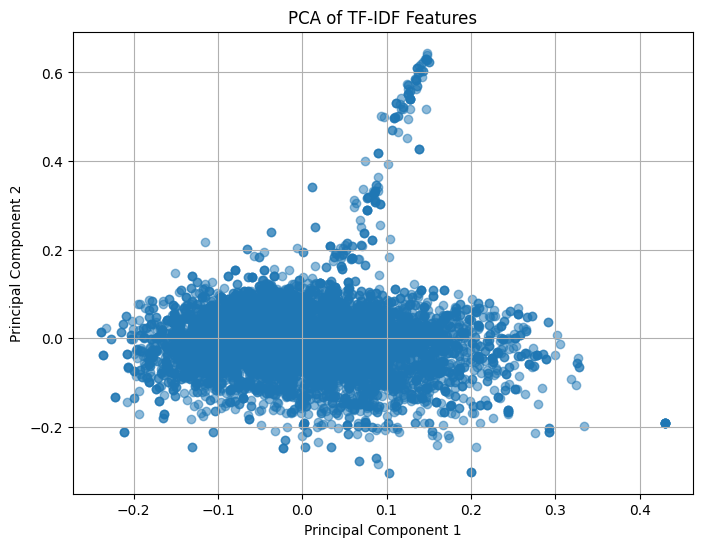

In [19]:
# trying to reduce dimensions to check model performance with either pca reduced data or x_tfidf data
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to TF-IDF features
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_pca = pca.fit_transform(X_tfidf.toarray())  # Convert sparse matrix to dense for PCA

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('PCA of TF-IDF Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

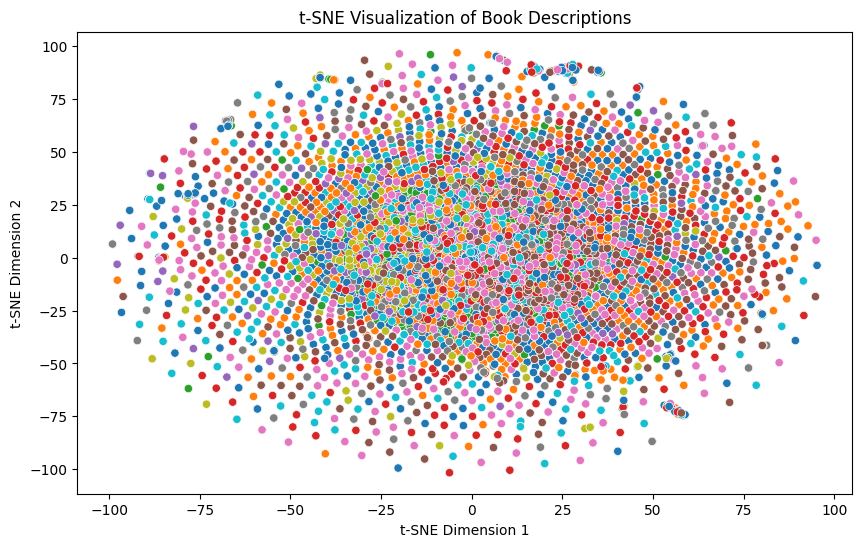

In [20]:
from sklearn.manifold import TSNE
import seaborn as sns

# Apply t-SNE to reduce dimensions to 2 for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_tfidf.toarray())

# Visualize t-SNE results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_clean_1['Genre'], palette='tab10', legend=None)
plt.title('t-SNE Visualization of Book Descriptions')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

we see that there are no defined clusters in the tf-idf encoded data, we do not need clustering data to improve classification outcome. Thus we will omit clustering the dataset.
We will now move to splitting our dataset into testing and training and then towards model building and evaluation.

In [ ]:

# # Step 2: Encode Target Labels
# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(df_balanced['Genre'])


In [ ]:

# # Step 3: Split Dataset
# X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# # Print dataset shapes to verify
# print(f"Training Features Shape: {X_train.shape}")
# print(f"Testing Features Shape: {X_test.shape}")
# print(f"Training Labels Shape: {y_train.shape}")
# print(f"Testing Labels Shape: {y_test.shape}")

Training Features Shape: (2371, 1000)
Testing Features Shape: (593, 1000)
Training Labels Shape: (2371,)
Testing Labels Shape: (593,)


### **STEP 4 : Model Build and evaluation**

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_clean_1['Genre'])

**Multinomial Logistic Regression model**

In [112]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
from imblearn.over_sampling import SMOTE

tfidf = TfidfVectorizer(max_features=8000, stop_words='english', ngram_range=(1, 2)) 
X_tfidf = tfidf.fit_transform(df_clean_1['Processed_Description'])
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_tfidf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_1, y_train_1)

# Train the baseline model
baseline_model = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial', solver='lbfgs',class_weight='balanced')
baseline_model.fit(X_resampled, y_resampled)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test_1)

# Evaluate the model
print("Baseline Model (Logistic Regression) Results:")
print("Accuracy:", accuracy_score(y_test_1, y_pred_baseline))
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_baseline))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_1, y_pred_baseline))

C:\Users\mahes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline Model (Logistic Regression) Results:
Accuracy: 0.710204081632653

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75        36
           1       0.79      0.79      0.79        19
           2       0.77      0.85      0.81        96
           3       0.88      0.88      0.88         8
           4       0.88      0.82      0.85        17
           5       0.61      0.74      0.67        19
           6       0.82      0.78      0.80        18
           7       1.00      0.83      0.91         6
           8       0.72      0.70      0.71       144
           9       0.55      0.43      0.49       200
          10       0.74      0.53      0.62        32
          11       0.77      0.69      0.73       143
          12       0.77      0.79      0.78       154
          13       0.53      0.69      0.60        67
          14       0.78      0.75      0.76        80
          15       0.65      0.74    

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_resampled, y_resampled)
y_pred_rf = rf_model.predict(X_test_1)

# Evaluate models
models = {
    "Random Forest": (rf_model, y_pred_rf)
}

for name, (model, y_pred) in models.items():
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test_1, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test_1, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_1, y_pred))



Random Forest Results:
Accuracy: 0.7626822157434402

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        36
           1       0.93      0.68      0.79        19
           2       0.86      0.83      0.85        96
           3       1.00      0.88      0.93         8
           4       1.00      0.82      0.90        17
           5       0.87      0.68      0.76        19
           6       0.70      0.78      0.74        18
           7       1.00      0.83      0.91         6
           8       0.75      0.69      0.72       144
           9       0.51      0.48      0.50       200
          10       0.78      0.56      0.65        32
          11       0.90      0.78      0.83       143
          12       0.88      0.77      0.82       154
          13       0.70      0.87      0.77        67
          14       0.92      0.69      0.79        80
          15       0.67      0.93      0.78       153
    

In [24]:
# Check the length of your feature matrix and target labels
print("Number of samples in tfidf_gb:", X_tfidf.shape[0])
print("Number of samples in y_encoded:", len(y_encoded))

Number of samples in tfidf_gb: 8573
Number of samples in y_encoded: 8573


In [25]:
# Check the mapping of labels to ensure everything is correctly encoded
print("Class labels after encoding:", label_encoder.classes_)


Class labels after encoding: ['Adventure fiction' 'Autobiographies' 'Biography' 'Business'
 "Children's literature" 'Classics' 'Contemporary romance' 'Fairy tale'
 'Fantasy' 'Fiction' 'Historical' 'Historical Fiction' 'Horror'
 'Literary fiction' 'Mystery' 'Other' 'Philosophy' 'Romance novel'
 'Science fiction' 'Thriller' "Women's fiction" 'Young adult']


**Gradient Boosting Classification**

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer



# First, apply TfidfVectorizer to convert text into feature vectors
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english')

# Fit and transform the training data into a TF-IDF matrix
tfidf_gb = vectorizer.fit_transform(df_clean_1['Processed_Description'])  
print(tfidf_gb.shape)
print(y_encoded.shape)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(tfidf_gb, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(X_train_gb.shape)
print(X_test_gb.shape)

smote = SMOTE(random_state=42)
X_resampled_xgb, y_resampled_xgb = smote.fit_resample(X_train_gb, y_train_gb)
gb_model.fit(X_resampled_xgb, y_resampled_xgb)
y_pred_gb = gb_model.predict(X_test_gb)


# Evaluate models
models = {
    "Gradient Boosting": (gb_model, y_pred_gb)
}

for name, (model, y_pred_gb) in models.items():
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test_gb, y_pred_gb))
    print("\nClassification Report:")
    print(classification_report(y_test_gb, y_pred_gb))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_gb, y_pred_gb))

(8573, 1000)
(8573,)
(6858, 1000)
(1715, 1000)

Gradient Boosting Results:
Accuracy: 0.6583090379008746

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.81      0.67        36
           1       0.57      0.68      0.62        19
           2       0.73      0.75      0.74        96
           3       1.00      0.88      0.93         8
           4       0.54      0.82      0.65        17
           5       0.58      0.74      0.65        19
           6       0.62      0.89      0.73        18
           7       0.45      0.83      0.59         6
           8       0.65      0.59      0.62       144
           9       0.49      0.29      0.37       200
          10       0.65      0.69      0.67        32
          11       0.73      0.60      0.66       143
          12       0.68      0.75      0.71       154
          13       0.66      0.78      0.71        67
          14       0.66      0.65      0.65        80
       

**XG BOOST**

In [237]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/124.9 MB 10.1 MB/s eta 0:00:13
    --------------------------------------- 1.8/124.9 MB 4.4 MB/s eta 0:00:29
    --------------------------------------- 2.4/124.9 MB 4.2 MB/s eta 0:00:30
   - -------------------------------------- 3.1/124.9 MB 3.7 MB/s eta 0:00:34
   - -------------------------------------- 3.7/124.9 MB 3.6 MB/s eta 0:00:34
   - -------------------------------------- 4.2/124.9 MB 3.5 MB/s eta 0:00:35
   - -------------------------------------- 5.0/124.9 MB 3.4 MB/s eta 0:00:36
   - -------------------------------------- 5.5/124.9 MB 3.4 MB/s eta 0:00:36
   - -------------------------------------- 6.0/124.9 MB 3.3 MB/s eta 0:00:37
   -- ------------------------------------- 6.8/124.9 MB 3.3 MB/s eta 0:00:37
   -- ------------------------------------- 7.3/124.9 MB 3.2 MB/s eta 

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

# First, apply TfidfVectorizer to convert text into feature vectors
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), stop_words='english')

# Fit and transform the training data into a TF-IDF matrix
tfidf_gb = vectorizer.fit_transform(df_clean_1['Processed_Description'])  
print(tfidf_gb.shape)
print(y_encoded.shape)

# Split the data into training and test sets
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(tfidf_gb, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Train the model
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_resampled_xgb, y_resampled_xgb = smote.fit_resample(X_train_xgb, y_train_xgb)

xgb_model.fit(X_resampled_xgb, y_resampled_xgb)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Evaluate the model
print("\nXGBoost Results:")
print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_xgb, y_pred_xgb))


(8573, 2000)
(8573,)


C:\Users\mahes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\core.py:158: UserWarning: [10:11:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Results:
Accuracy: 0.7667638483965015

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        36
           1       1.00      0.68      0.81        19
           2       0.83      0.86      0.85        96
           3       0.88      0.88      0.88         8
           4       0.88      0.82      0.85        17
           5       0.86      0.63      0.73        19
           6       0.88      0.78      0.82        18
           7       1.00      0.83      0.91         6
           8       0.76      0.71      0.73       144
           9       0.56      0.43      0.49       200
          10       0.95      0.62      0.75        32
          11       0.83      0.83      0.83       143
          12       0.79      0.83      0.81       154
          13       0.78      0.85      0.81        67
          14       0.78      0.74      0.76        80
          15       0.70      0.88      0.78       153
          

In [34]:
print(xgb_model.get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'mlogloss', 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': False}


**SVM**

In [28]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC

# Support Vector Machine
svm_model = SVC(random_state=42)
svm_model.fit(X_resampled, y_resampled)
y_pred_svm = svm_model.predict(X_test_1)

# Evaluate models
models = {
    "SVM": (svm_model, y_pred_svm)
}

for name, (model, y_pred) in models.items():
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test_1, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test_1, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_1, y_pred))


SVM Results:
Accuracy: 0.7486880466472303

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86        36
           1       1.00      0.68      0.81        19
           2       0.98      0.67      0.80        96
           3       1.00      0.88      0.93         8
           4       1.00      0.82      0.90        17
           5       1.00      0.63      0.77        19
           6       1.00      0.78      0.88        18
           7       1.00      0.83      0.91         6
           8       0.83      0.73      0.77       144
           9       0.35      0.87      0.50       200
          10       1.00      0.44      0.61        32
          11       0.93      0.74      0.82       143
          12       0.92      0.79      0.85       154
          13       0.94      0.69      0.79        67
          14       1.00      0.68      0.81        80
          15       0.84      0.73      0.78       153
          16  

**HistGradientBoostingClassifier**

In [29]:
from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Assuming df_clean is already defined and has a 'Genre' column for classification
# Define your features (X) and target variable (y)
# X = df_clean['Processed_Description']  # Adjust as per your data processing
# y = df_clean['Genre']

# Apply TfidfVectorizer (or other preprocessing) to convert text to features
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english')
X_tfidf = vectorizer.fit_transform(df_clean_1['Processed_Description'])

# Split the data into training and test sets
X_train_hgd, X_test_hgd, y_train_hgd, y_test_hgd = train_test_split(X_tfidf.toarray(), y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_resampled_hgd, y_resampled_hgd = smote.fit_resample(X_train_hgd, y_train_hgd)

# Set up HistGradientBoostingClassifier with early stopping
hist_gb = HistGradientBoostingClassifier(
    max_iter=100,  # Max number of iterations (boosting rounds)
    random_state=42,
    early_stopping=True,  # Enable early stopping
    n_iter_no_change=10,  # Number of iterations without improvement before stopping
    validation_fraction=0.1,  # Fraction of training data to use for early stopping validation
    tol=1e-4  # Tolerance for improvement in validation score
)

# Fit the model
hist_gb.fit(X_resampled_hgd, y_resampled_hgd)

# Make predictions on the test set
y_pred = hist_gb.predict(X_test_hgd)

# Evaluate the model
print("HistGradientBoostingClassifier Results:")
print("Accuracy:", accuracy_score(y_test_hgd, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_hgd, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_hgd, y_pred))


C:\Users\mahes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:16: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


HistGradientBoostingClassifier Results:
Accuracy: 0.749271137026239

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        36
           1       0.93      0.68      0.79        19
           2       0.83      0.84      0.84        96
           3       0.78      0.88      0.82         8
           4       0.93      0.82      0.88        17
           5       0.71      0.63      0.67        19
           6       0.88      0.83      0.86        18
           7       1.00      0.83      0.91         6
           8       0.73      0.67      0.70       144
           9       0.48      0.44      0.46       200
          10       0.91      0.66      0.76        32
          11       0.80      0.82      0.81       143
          12       0.81      0.84      0.82       154
          13       0.72      0.79      0.75        67
          14       0.81      0.76      0.79        80
          15       0.70      0.84      0.77

**To optimize our models, we'll use GridSearchCV for hyperparameter tuning:**

In [30]:
from sklearn.model_selection import GridSearchCV

# Random Forest hyperparameter tuning
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [ None,10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, n_jobs=-1)
rf_grid.fit(X_resampled, y_resampled)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest Score:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Random Forest Score: 0.9169448827307638


In [38]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import numpy as np


# Define the parameter distribution with reduced search space
param_dist = {
    'learning_rate': uniform(0.01, 0.04),  # Reduced learning rate range
    'max_depth': randint(3, 8),             # Reduced max depth range
    'n_estimators': randint(50, 150),      # Reduced number of estimators
    'subsample': uniform(0.7, 0.3),         # Reduced subsample range
    'colsample_bytree': uniform(0.7, 0.3),  # Reduced column sample range
    'min_child_weight': randint(1, 6),      # Reduced min_child_weight range
    'gamma': uniform(0, 0.5),               # Reduced gamma range
    'reg_alpha': uniform(0, 0.5),           # Reduced L1 regularization
    'reg_lambda': uniform(0, 0.5),          # Reduced L2 regularization
}

# Initialize the XGBClassifier
xgb = XGBClassifier(random_state=42, use_label_encoder=False)


random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,          # Reduced number of iterations
    cv=3,               # Reduced cross-validation folds to speed up
    verbose=2,          # Show progress
    n_jobs=-1,          # Use all cores
    random_state=42
)


# Split data for validation set
X_train_sub, X_valid, y_train_sub, y_valid = train_test_split(X_resampled_xgb, y_resampled_xgb, test_size=0.2, random_state=42)

# Fit the RandomizedSearchCV using the custom fit function
random_search.fit(X_train_sub, y_train_sub, eval_set=[(X_valid, y_valid)])

# Output the best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)



Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\mahes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\core.py:158: UserWarning: [12:45:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	validation_0-mlogloss:2.87393
[1]	validation_0-mlogloss:2.71051
[2]	validation_0-mlogloss:2.57739
[3]	validation_0-mlogloss:2.45744
[4]	validation_0-mlogloss:2.35452
[5]	validation_0-mlogloss:2.26440
[6]	validation_0-mlogloss:2.17980
[7]	validation_0-mlogloss:2.10497
[8]	validation_0-mlogloss:2.03582
[9]	validation_0-mlogloss:1.97439
[10]	validation_0-mlogloss:1.91601
[11]	validation_0-mlogloss:1.86379
[12]	validation_0-mlogloss:1.81233
[13]	validation_0-mlogloss:1.76473
[14]	validation_0-mlogloss:1.71921
[15]	validation_0-mlogloss:1.67543
[16]	validation_0-mlogloss:1.63578
[17]	validation_0-mlogloss:1.59771
[18]	validation_0-mlogloss:1.56181
[19]	validation_0-mlogloss:1.52824
[20]	validation_0-mlogloss:1.49497
[21]	validation_0-mlogloss:1.46326
[22]	validation_0-mlogloss:1.43254
[23]	validation_0-mlogloss:1.40374
[24]	validation_0-mlogloss:1.37647
[25]	validation_0-mlogloss:1.34974
[26]	validation_0-mlogloss:1.32476
[27]	validation_0-mlogloss:1.30131
[28]	validation_0-mlogloss:1.2

In [36]:

from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Set up HistGradientBoostingClassifier with early stopping
hist_gb = HistGradientBoostingClassifier(
    max_iter=100,  # Max number of iterations (boosting rounds)
    random_state=42,
    early_stopping=True,  # Enable early stopping
    n_iter_no_change=10,  # Number of iterations without improvement before stopping
    validation_fraction=0.1,  # Fraction of training data to use for early stopping validation
    tol=1e-4  # Tolerance for improvement in validation score
)

# Define the parameter grid for RandomizedSearchCV
gb_params = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [1, 2], 
    'max_bins': [2, 32, 64, 128, 255],  # max_bins is an important parameter for HistGradientBoosting
    'max_leaf_nodes': [31, 63, 127],  # max_leaf_nodes parameter for HistGradientBoosting
}

# Use RandomizedSearchCV for HistGradientBoostingClassifier
gb_random = RandomizedSearchCV(
    hist_gb,
    gb_params,
    n_iter=10,  # Number of iterations to try for randomized search
    cv=5,  # Cross-validation splits
    n_jobs=-1,  # Use all available cores for parallelization
    random_state=42
)

# Fit the model
gb_random.fit(X_resampled_hgd, y_resampled_hgd)

# Print best parameters and score
print("Best Gradient Boosting Parameters:", gb_random.best_params_)
print("Best Gradient Boosting Score:", gb_random.best_score_)



Best Gradient Boosting Parameters: {'min_samples_leaf': 1, 'max_leaf_nodes': 127, 'max_depth': 4, 'max_bins': 32, 'learning_rate': 0.1}
Best Gradient Boosting Score: 0.8843480969742871


**Final Classification Results \
Now, let's evaluate our best models on the test set:**

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Best hyperparameters from RandomizedSearchCV
best_rf_params = {
    'max_depth': None,               # No restriction on the maximum depth of trees
    'min_samples_leaf': 1,           # Minimum number of samples required to be at a leaf node
    'min_samples_split': 2,          # Minimum number of samples required to split an internal node
    'n_estimators': 300,            # Number of trees in the forest
    'random_state': 42              # For reproducibility
}

# Initialize the RandomForestClassifier with the best parameters
rf_model_optimized = RandomForestClassifier(**best_rf_params)

# Fit the optimized model to the resampled training data
rf_model_optimized.fit(X_resampled, y_resampled)

# Predict on the test set
y_pred_rf_optimized = rf_model_optimized.predict(X_test_1)

# # Optional: Evaluate the model (e.g., accuracy)
# from sklearn.metrics import accuracy_score
# accuracy = accuracy_score(y_test_1, y_pred_rf_optimized)
# print(f"Accuracy of Optimized Random Forest Model: {accuracy:.4f}")

# # Final evaluation
best_models = {
    "Best Random Forest": (rf_model_optimized, y_pred_rf_optimized)
}

for name, (model, y_pred) in best_models.items():
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test_1, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test_1, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_1, y_pred))




Best Random Forest Results:
Accuracy: 0.7731778425655976

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85        36
           1       1.00      0.68      0.81        19
           2       0.90      0.83      0.86        96
           3       1.00      0.88      0.93         8
           4       1.00      0.82      0.90        17
           5       0.93      0.68      0.79        19
           6       0.70      0.78      0.74        18
           7       1.00      0.83      0.91         6
           8       0.76      0.67      0.71       144
           9       0.57      0.49      0.53       200
          10       0.86      0.56      0.68        32
          11       0.88      0.81      0.84       143
          12       0.85      0.80      0.82       154
          13       0.72      0.90      0.80        67
          14       0.93      0.70      0.80        80
          15       0.69      0.96      0.80       153

In [42]:
from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

# Assuming df_clean_1 is already defined and has a 'Processed_Description' column for text classification
# X = df_clean_1['Processed_Description']  # Adjust as per your data processing
# y = df_clean_1['Genre']

# Apply TfidfVectorizer (or other preprocessing) to convert text to features
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english')
X_tfidf = vectorizer.fit_transform(df_clean_1['Processed_Description'])

# Split the data into training and test sets
X_train_hgd, X_test_hgd, y_train_hgd, y_test_hgd = train_test_split(X_tfidf.toarray(), y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Apply SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled_hgd, y_resampled_hgd = smote.fit_resample(X_train_hgd, y_train_hgd)

# Set up HistGradientBoostingClassifier with the best parameters
hist_gb = HistGradientBoostingClassifier(
    max_iter=100,                # Max number of iterations (boosting rounds)
    random_state=42,
    early_stopping=True,         # Enable early stopping
    n_iter_no_change=10,         # Number of iterations without improvement before stopping
    validation_fraction=0.1,     # Fraction of training data to use for early stopping validation
    tol=1e-4,                    # Tolerance for improvement in validation score
    min_samples_leaf=1,          # Minimum samples per leaf
    max_leaf_nodes=127,          # Maximum number of leaf nodes
    max_depth=4,                 # Maximum depth of trees
    max_bins=32,                 # Maximum number of bins used for histograms
    learning_rate=0.1            # Learning rate for boosting
)

# Fit the model
hist_gb.fit(X_resampled_hgd, y_resampled_hgd)

# Make predictions on the test set
y_pred = hist_gb.predict(X_test_hgd)

# Evaluate the model
print("HistGradientBoostingClassifier Results:")
print("Accuracy:", accuracy_score(y_test_hgd, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_hgd, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_hgd, y_pred))


HistGradientBoostingClassifier Results:
Accuracy: 0.7358600583090379

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.86      0.79        36
           1       0.81      0.68      0.74        19
           2       0.84      0.77      0.80        96
           3       1.00      0.88      0.93         8
           4       0.82      0.82      0.82        17
           5       0.62      0.68      0.65        19
           6       0.84      0.89      0.86        18
           7       1.00      0.83      0.91         6
           8       0.69      0.61      0.65       144
           9       0.59      0.40      0.48       200
          10       0.77      0.72      0.74        32
          11       0.84      0.82      0.83       143
          12       0.79      0.76      0.77       154
          13       0.66      0.88      0.76        67
          14       0.86      0.74      0.79        80
          15       0.67      0.89      0.7

**Exporting RandomForest model**

In [44]:
import pickle

# Save the trained model to a file using pickle
with open('rf_model_optimized.pkl', 'wb') as model_file:
    pickle.dump(rf_model_optimized, model_file)

print("Model saved successfully!")


Model saved successfully!


In [68]:
# To load the model later
with open('rf_model_optimized.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

# Test loading the model by making predictions on test data
y_pred_loaded_model = loaded_model.predict(X_test_1)
print("Loaded Model Accuracy:", accuracy_score(y_test_1, y_pred_loaded_model))


Loaded Model Accuracy: 0.7731778425655976


In [16]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Preprocess the text data
max_words = 10000
max_length = 200

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df_clean_1['Processed_Description'])
sequences = tokenizer.texts_to_sequences(df_clean_1['Processed_Description'])
X = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

# Encode the genres
le = LabelEncoder()
y = le.fit_transform(df_clean_1['Genre'])
y = to_categorical(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the LSTM model
model = Sequential([
    Embedding(max_words, 100, input_length=max_length),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(y.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {accuracy:.4f}')

Epoch 1/10


C:\Users\mahes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


193/193 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.0884 - loss: 2.9279 - val_accuracy: 0.1137 - val_loss: 2.7742
Epoch 2/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.1047 - loss: 2.8015 - val_accuracy: 0.1152 - val_loss: 2.7604
Epoch 3/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.1048 - loss: 2.7697 - val_accuracy: 0.1152 - val_loss: 2.7588
Epoch 4/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.1106 - loss: 2.7652 - val_accuracy: 0.1152 - val_loss: 2.7549
Epoch 5/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.1122 - loss: 2.7543 - val_accuracy: 0.1152 - val_loss: 2.7520
Epoch 6/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.1059 - loss: 2.7405 - val_accuracy: 0.1166 - val_loss: 2.7509
Epoch 7/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.1227 - loss: 2.7235 - val_accuracy: 0.1137 - val_loss: 2.7609
Epoch 8/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.1129 - loss: 2.7592 - val_acc

HistGradientBoostingClassifier Results:
Accuracy: 0.7358600583090379

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.86      0.79        36
           1       0.81      0.68      0.74        19
           2       0.84      0.77      0.80        96
           3       1.00      0.88      0.93         8
           4       0.82      0.82      0.82        17
           5       0.62      0.68      0.65        19
           6       0.84      0.89      0.86        18
           7       1.00      0.83      0.91         6
           8       0.69      0.61      0.65       144
           9       0.59      0.40      0.48       200
          10       0.77      0.72      0.74        32
          11       0.84      0.82      0.83       143
          12       0.79      0.76      0.77       154
          13       0.66      0.88      0.76        67
          14       0.86      0.74      0.79        80
          15       0.67      0.89      0.7

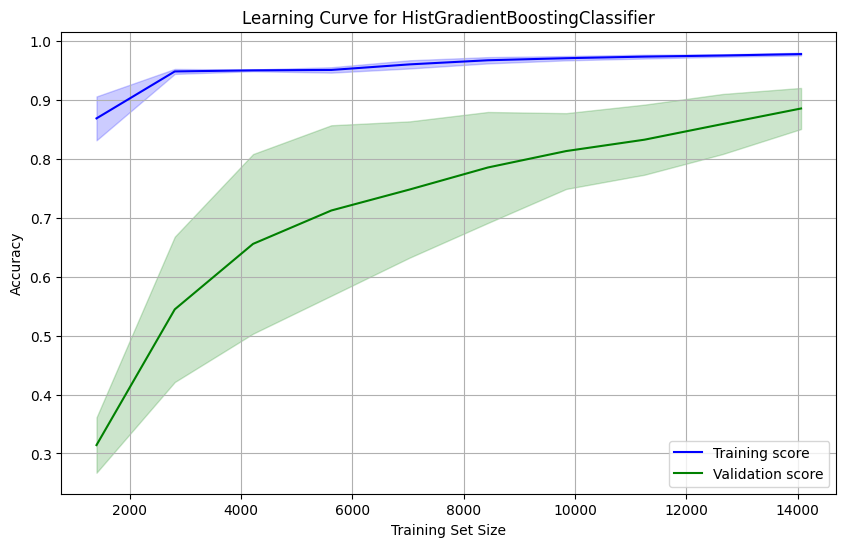

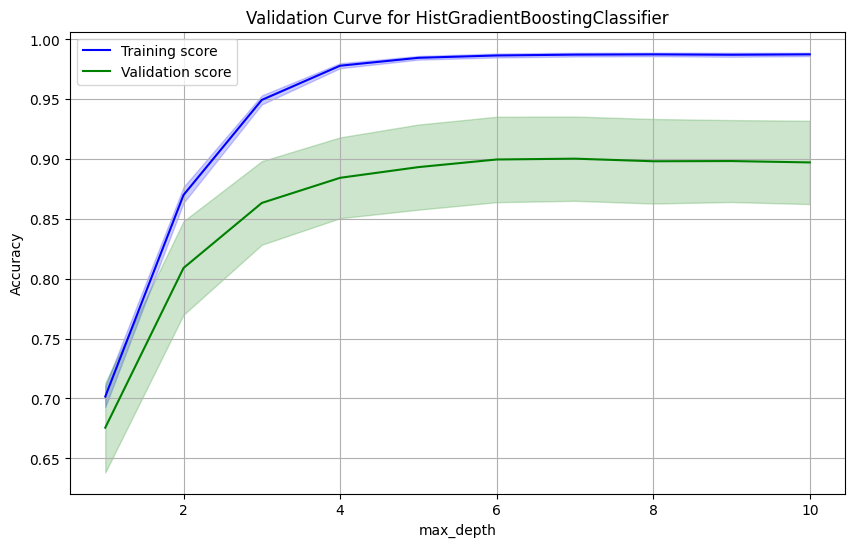

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, validation_curve, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Assuming you already have a DataFrame `df_clean_1` with 'Processed_Description' and 'Genre' columns

# Apply TfidfVectorizer to convert text data into numerical features
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english')
X_tfidf = vectorizer.fit_transform(df_clean_1['Processed_Description'])

# Assuming y_encoded is your target labels (encoded genres)
X_train_hgd, X_test_hgd, y_train_hgd, y_test_hgd = train_test_split(X_tfidf.toarray(), y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Apply SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42)
X_resampled_hgd, y_resampled_hgd = smote.fit_resample(X_train_hgd, y_train_hgd)

# Set up HistGradientBoostingClassifier with hyperparameters
hist_gb = HistGradientBoostingClassifier(
    max_iter=100,                # Max number of boosting iterations
    random_state=42,
    early_stopping=True,         # Enable early stopping
    n_iter_no_change=10,         # Stop after 10 iterations without improvement
    validation_fraction=0.1,     # Fraction of training data for early stopping validation
    tol=1e-4,                    # Tolerance for improvement in validation score
    min_samples_leaf=1,          # Minimum samples per leaf
    max_leaf_nodes=127,          # Maximum number of leaf nodes
    max_depth=4,                 # Maximum depth of the trees
    max_bins=32,                 # Maximum number of bins in histogram
    learning_rate=0.1            # Learning rate
)

# Fit the HistGradientBoostingClassifier
hist_gb.fit(X_resampled_hgd, y_resampled_hgd)

# Make predictions on the test set
y_pred = hist_gb.predict(X_test_hgd)

# Evaluate the model
print("HistGradientBoostingClassifier Results:")
print("Accuracy:", accuracy_score(y_test_hgd, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_hgd, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_hgd, y_pred))

# ---- Plot Learning Curve ----
train_sizes, train_scores, val_scores = learning_curve(
    hist_gb,                     # The model to evaluate
    X_resampled_hgd,             # Features (training data)
    y_resampled_hgd,             # Labels (training labels)
    cv=StratifiedKFold(n_splits=5),  # Cross-validation strategy
    n_jobs=-1,                   # Use all processors for parallel computation
    train_sizes=np.linspace(0.1, 1.0, 10),  # Fraction of data to train on
    scoring='accuracy'           # Scoring metric (accuracy)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
val_scores_std = val_scores.std(axis=1)

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label="Training score", color="blue")
plt.plot(train_sizes, val_scores_mean, label="Validation score", color="green")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, color="blue", alpha=0.2)
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, color="green", alpha=0.2)
plt.title("Learning Curve for HistGradientBoostingClassifier")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ---- Plot Validation Curve ----
param_range = np.arange(1, 11)  # Range of values for the 'max_depth' hyperparameter

train_scores, val_scores = validation_curve(
    hist_gb,                     # The model to evaluate
    X_resampled_hgd,             # Features (training data)
    y_resampled_hgd,             # Labels (training labels)
    param_name="max_depth",      # Hyperparameter to vary
    param_range=param_range,    # Values of max_depth to try
    cv=StratifiedKFold(n_splits=5),  # Cross-validation strategy
    n_jobs=-1,                   # Use all processors for parallel computation
    scoring='accuracy'           # Scoring metric (accuracy)
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
val_scores_std = val_scores.std(axis=1)

# Plot Validation Curve
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_scores_mean, label="Training score", color="blue")
plt.plot(param_range, val_scores_mean, label="Validation score", color="green")
plt.fill_between(param_range, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, color="blue", alpha=0.2)
plt.fill_between(param_range, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, color="green", alpha=0.2)
plt.title("Validation Curve for HistGradientBoostingClassifier")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


The decision to select the HistGradientBoostingClassifier for our genre classification model was based on a comprehensive evaluation of its performance compared to other algorithms. As shown in the validation and learning curves, the HistGradientBoostingClassifier exhibited robust performance with increasing dataset size, maintaining high accuracy and a stable increase in validation scores, which suggests effective generalization.

While models like Random Forest also displayed commendable accuracy, their learning and validation curves indicated potential overfitting issues, as they did not converge as reliably with an increase in training data size. This overfitting diminishes the model’s ability to generalize to new, unseen data, which is crucial for a reliable recommendation system.

In contrast, the HistGradientBoostingClassifier managed to balance bias and variance effectively, achieving high accuracy without the overfitting seen in other models. This balance is critical in our application, where the ability to accurately classify and recommend books across diverse genres can significantly enhance user satisfaction. The depth of analysis possible with the HistGradientBoostingClassifier, alongside its efficient handling of sparse data, ultimately guided our choice, aiming for a model that not only performs well on current data but is also scalable and adaptable to future dataset variations.

### LLM And Recommendation system interface

In [ ]:
import streamlit as st
import pandas as pd
import openai

# Load dataset
@st.cache
def load_data():
    return pd.read_csv("BooksDataSet_project.csv")

df = load_data()
df['Genre'] = df['Genre'].str.lower()
df['Author'] = df['Author'].str.lower()
df['Book'] = df['Book'].str.lower()

# OpenAI API Key
openai.api_key = st.secrets["OPENAI_API_KEY"]

# Function to process user queries
def process_query(query):
    query = query.lower()
    
    # Check for author-related queries
    if "books by" in query or "author" in query:
        author_name = query.split("by")[-1].strip()
        author_books = df[df['Author'] == author_name]
        count = len(author_books)
        if count > 0:
            return f"{author_name.title()} has written {count} book(s): {', '.join(author_books['Book'].tolist())}."
        else:
            return f"No books found for the author '{author_name.title()}'."
    
    # Check for similar books
    elif "similar books" in query or "same genre" in query:
        book_title = query.split("books like")[-1].strip()
        if book_title in df['Book'].values:
            genre = df[df['Book'] == book_title].iloc[0]['Genre']
            similar_books = df[df['Genre'] == genre]['Book'].tolist()
            similar_books.remove(book_title)
            if similar_books:
                return f"Books similar to '{book_title.title()}': {', '.join(similar_books[:10])}."
            else:
                return f"No similar books found for '{book_title.title()}'."
        else:
            return f"The book '{book_title.title()}' is not found in the dataset."
    
    # Check for book ratings
    elif "rating of" in query:
        book_title = query.split("rating of")[-1].strip()
        book_info = df[df['Book'] == book_title]
        if not book_info.empty:
            avg_rating = book_info['Avg_Rating'].values[0]
            return f"The average rating of '{book_title.title()}' is {avg_rating}."
        else:
            return f"'{book_title.title()}' is not found in the dataset."
    
    # Default response for unrecognized queries
    else:
        return "I’m sorry, I couldn’t understand your query. Please try asking about books by an author, similar books, or ratings."

# Streamlit app interface
st.title("Book Recommendation and Query Chatbot")
st.write("Ask me about books, authors, genres, and ratings!")

# User input
user_query = st.text_input("Type your question here:")

# Process query on submit
if st.button("Submit"):
    if user_query:
        response = process_query(user_query)
        st.write(response)
    else:
        st.write("Please type a question!")

This code was used to deploy the project in streamlit. It trains the bot on our data and gives answers to user questions.Additional setup is done in the requirements file and environment file of streamlit. Working link on bot after deployement : https://agw36krceylfpyqkux4azr.streamlit.app/

--- 
THE END 
---

---